# 02 — Signal Inspection

**Purpose:** Visually inspect raw ECG signals across representative training and test records, assess signal quality, and decide whether to proceed to R-peak detection.

**Inputs:**
- Raw recordings in `data/raw/` (from notebook 01)
- `data/features/record_inventory.csv` (from notebook 01)

**Outputs:**
- `reports/figures/signal_inspection_training.png` — 4-record training figure
- `reports/figures/signal_inspection_test.png` — 3-record test figure
- Interactive widget for ad-hoc inspection of any record/window

![Status: COMPLETE](https://img.shields.io/badge/Status-COMPLETE-brightgreen)

In [1]:
# ── Cell 1: Imports and path setup ────────────────────────────────────────────
import pathlib
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import wfdb
import ipywidgets as widgets
from IPython.display import display

matplotlib.rcParams.update({"figure.dpi": 120, "font.size": 9})

RAW_DIR     = pathlib.Path("../data/raw")
FIGURES_DIR = pathlib.Path("../reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

inventory = pd.read_csv("../data/features/record_inventory.csv")
print(f"Inventory loaded: {len(inventory)} records")

Inventory loaded: 70 records


In [2]:
# ── Cell 2: Helper functions ───────────────────────────────────────────────────

def load_ecg(rec_id: str):
    """Return (signal_1d, fs) for the first ECG channel of a record."""
    rec = wfdb.rdrecord(str(RAW_DIR / rec_id))
    sig = rec.p_signal[:, 0]  # first channel
    return sig, rec.fs


def load_annotations(rec_id: str):
    """Return list of (sample_index, symbol) tuples from .apn file, or empty list."""
    ann_path = RAW_DIR / f"{rec_id}.apn"
    if not ann_path.exists():
        return []
    ann = wfdb.rdann(str(RAW_DIR / rec_id), extension="apn")
    return list(zip(ann.sample, ann.symbol))


def minute_label_at(annotations, minute_idx: int) -> str:
    """Return the annotation symbol for the given minute index, or '?' if unavailable."""
    for (samp, sym) in annotations:
        ann_min = samp  # minute index (converted from sample index on load)
        if ann_min == minute_idx:
            return sym
    return "?"


def plot_record_row(ax_left, ax_right, rec_id: str, title_prefix: str = ""):
    """
    Fill one figure row:
      ax_left  : 60-second raw ECG starting at minute 10
      ax_right : 5-minute ECG with vertical red lines at apnea minute boundaries
    """
    sig, fs = load_ecg(rec_id)
    anns    = load_annotations(rec_id)

    # ── Left: 60-second window ──────────────────────────────────────────────
    start_s  = 10 * 60          # start at minute 10
    n_60s    = int(60 * fs)
    start_i  = min(int(start_s * fs), len(sig) - n_60s)
    chunk    = sig[start_i : start_i + n_60s]
    t_60     = np.arange(len(chunk)) / fs

    ax_left.plot(t_60, chunk, lw=0.6, color="steelblue")
    ax_left.set_title(f"{title_prefix}{rec_id} — 60 s raw ECG (min 10)", fontsize=8)
    ax_left.set_xlabel("Time (s)", fontsize=7)
    ax_left.set_ylabel("mV", fontsize=7)
    ax_left.tick_params(labelsize=7)

    # ── Right: 5-minute window with apnea boundaries ────────────────────────
    n_5min  = int(5 * 60 * fs)
    start_i5 = min(int(start_s * fs), len(sig) - n_5min)
    chunk5   = sig[start_i5 : start_i5 + n_5min]
    t_5      = np.arange(len(chunk5)) / fs

    ax_right.plot(t_5, chunk5, lw=0.4, color="steelblue")
    ax_right.set_title(f"{title_prefix}{rec_id} — 5 min ECG with apnea boundaries", fontsize=8)
    ax_right.set_xlabel("Time (s)", fontsize=7)
    ax_right.set_ylabel("mV", fontsize=7)
    ax_right.tick_params(labelsize=7)

    start_min = start_i5 // (60 * fs)
    for m_offset in range(6):  # up to 6 boundaries across 5 minutes
        m_abs  = int(start_min) + m_offset
        sym    = minute_label_at(anns, m_abs)
        x_pos  = m_offset * 60.0
        color  = "red" if sym == "A" else ("green" if sym == "N" else "gray")
        ax_right.axvline(x=x_pos, color=color, lw=1.2, linestyle="--", alpha=0.8)
        ax_right.text(x_pos + 1, ax_right.get_ylim()[1] * 0.85 if ax_right.get_ylim()[1] != 0 else 0.5,
                      sym, fontsize=7, color=color)

    red_patch   = mpatches.Patch(color="red",   label="Apnea (A)")
    green_patch = mpatches.Patch(color="green", label="Normal (N)")
    ax_right.legend(handles=[red_patch, green_patch], fontsize=6, loc="upper right")

  Loading a01... done
  Loading a10... done
  Loading a20... done
  Loading a30... 

FileNotFoundError: [Errno 2] No such file or directory: '/Users/dennisray/sleepApnea/apnea-project/data/raw/a30.hea'

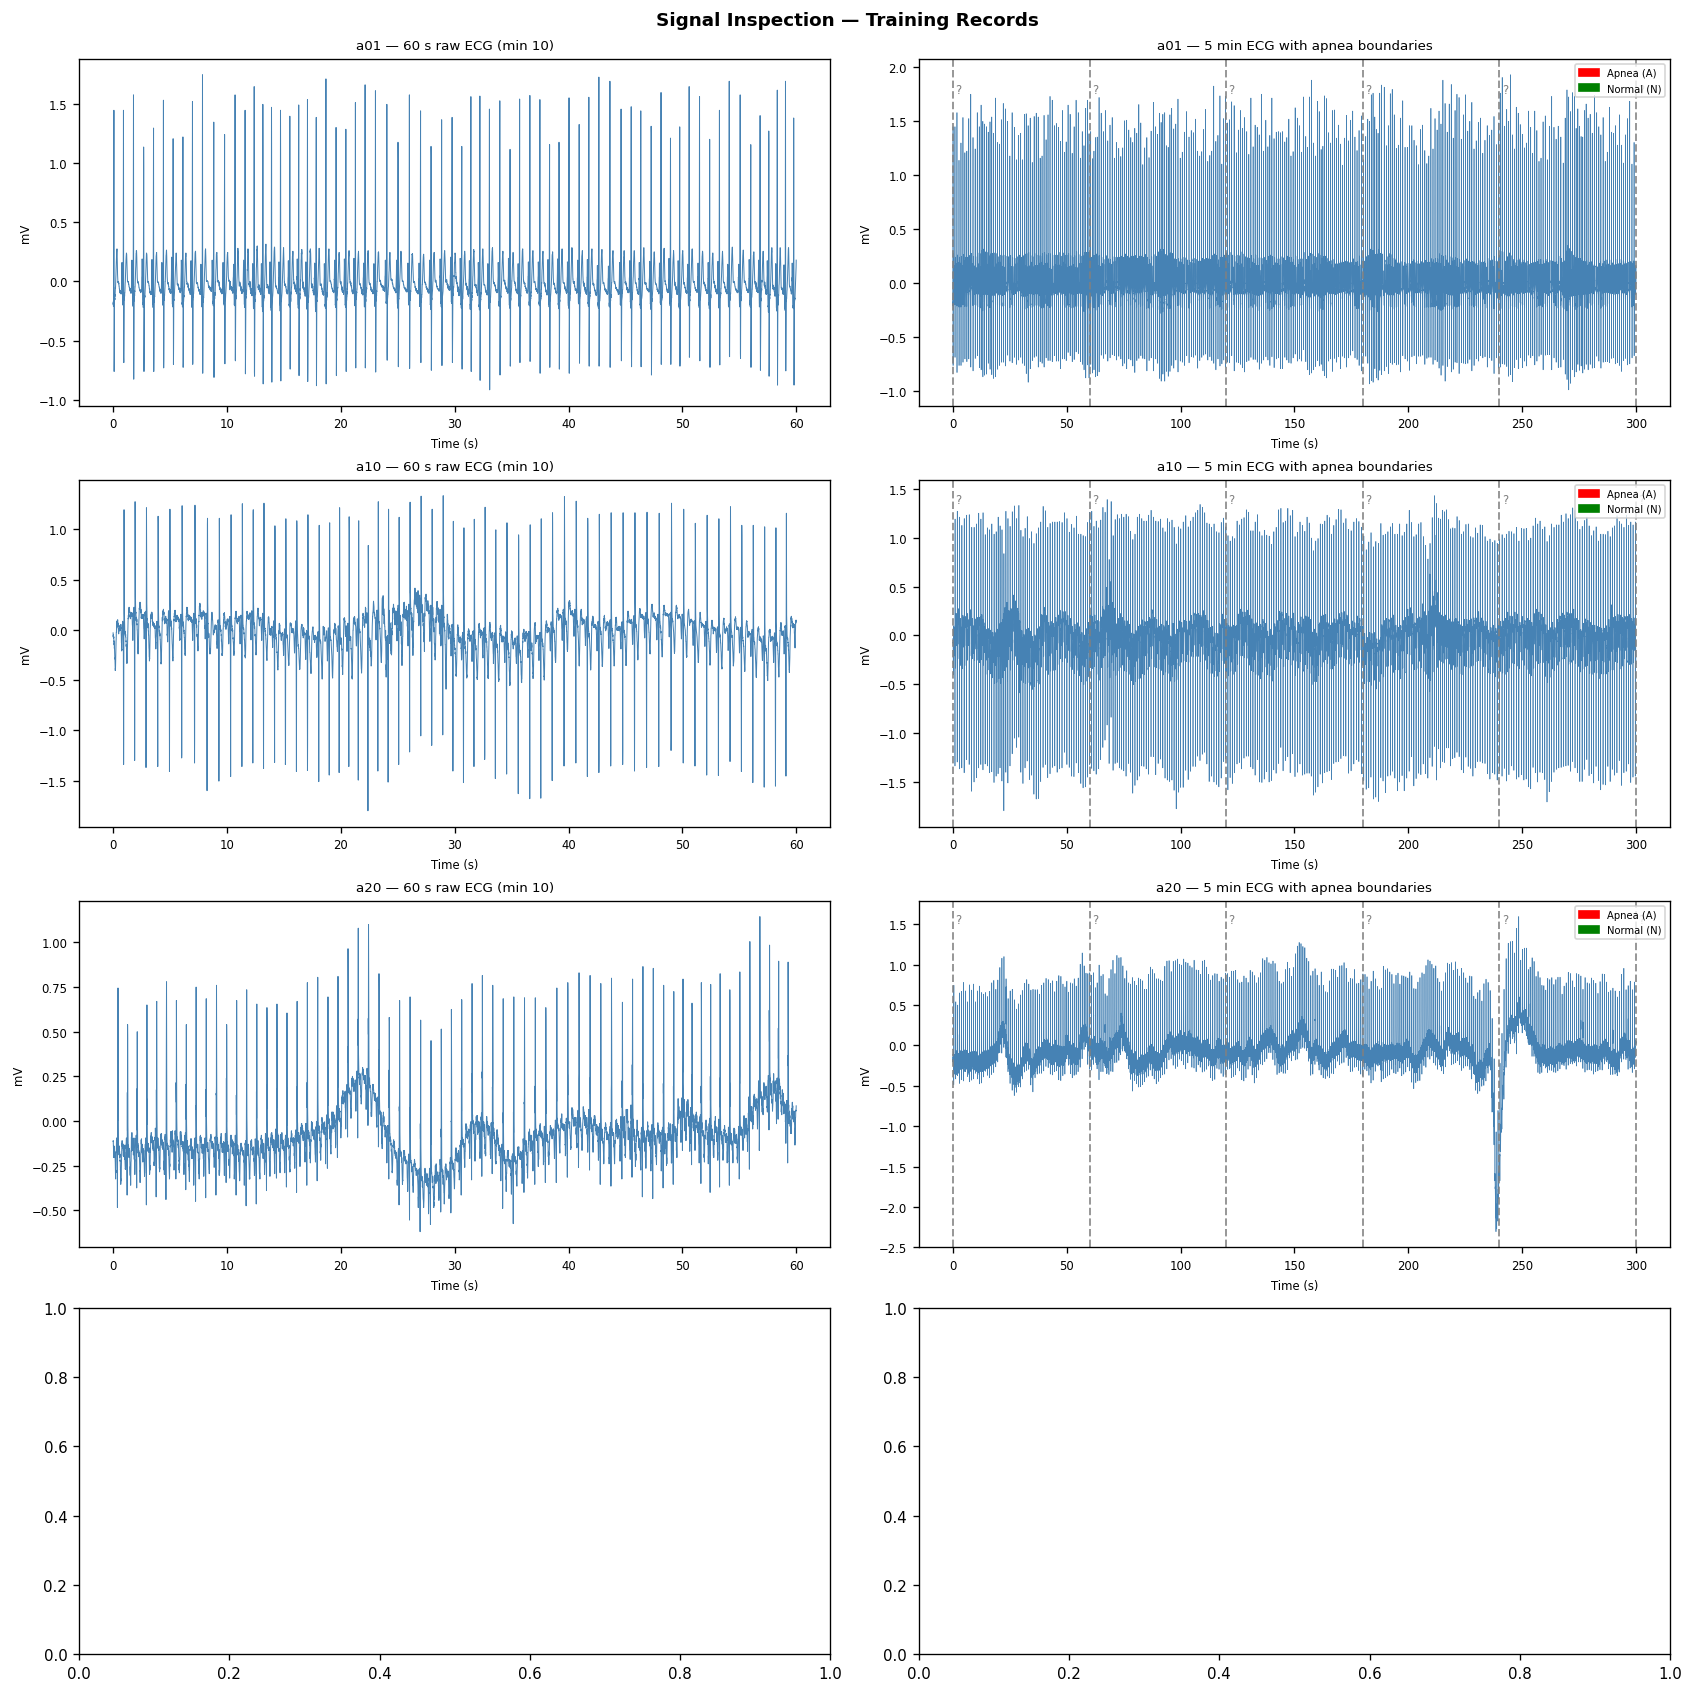

In [3]:
# ── Cell 3: Training records figure (a01, a10, a20, a30) ──────────────────────
TRAIN_RECORDS = ["a01", "a10", "a20", "a30"]

fig_train, axes_train = plt.subplots(
    nrows=len(TRAIN_RECORDS), ncols=2,
    figsize=(14, 3.5 * len(TRAIN_RECORDS)),
    constrained_layout=True
)
fig_train.suptitle("Signal Inspection — Training Records", fontsize=11, fontweight="bold")

for i, rec_id in enumerate(TRAIN_RECORDS):
    print(f"  Loading {rec_id}...", end=" ")
    plot_record_row(axes_train[i, 0], axes_train[i, 1], rec_id)
    print("done")

out_train = FIGURES_DIR / "signal_inspection_training.png"
fig_train.savefig(out_train, dpi=150)
plt.show()
print(f"Saved: {out_train.resolve()}")

In [ ]:
# ── Cell 4: Test records figure (b01, c01, x01) ───────────────────────────────
TEST_RECORDS = ["b01", "c01", "x01"]

fig_test, axes_test = plt.subplots(
    nrows=len(TEST_RECORDS), ncols=2,
    figsize=(14, 3.5 * len(TEST_RECORDS)),
    constrained_layout=True
)
fig_test.suptitle("Signal Inspection — Test Records", fontsize=11, fontweight="bold")

for i, rec_id in enumerate(TEST_RECORDS):
    print(f"  Loading {rec_id}...", end=" ")
    plot_record_row(axes_test[i, 0], axes_test[i, 1], rec_id)
    print("done")

out_test = FIGURES_DIR / "signal_inspection_test.png"
fig_test.savefig(out_test, dpi=150)
plt.show()
print(f"Saved: {out_test.resolve()}")

In [ ]:
# ── Cell 5: Interactive widget — any record × any start minute ────────────────
# Uses ipywidgets; requires a live Jupyter kernel (not nbconvert/static).

all_record_ids = sorted(inventory["record_id"].tolist())

# Pre-cache durations to set slider range dynamically
dur_map = dict(zip(inventory["record_id"], inventory["duration_minutes"].astype(int)))

rec_dropdown = widgets.Dropdown(
    options=all_record_ids,
    value="a01",
    description="Record:",
    layout=widgets.Layout(width="180px")
)
start_slider = widgets.IntSlider(
    value=10,
    min=0,
    max=dur_map.get("a01", 480) - 1,
    step=1,
    description="Start min:",
    continuous_update=False,
    layout=widgets.Layout(width="400px")
)
out_widget = widgets.Output()

def update_slider_max(change):
    """Adjust slider max when the selected record changes."""
    new_max = dur_map.get(change["new"], 480) - 1
    start_slider.max = new_max
    start_slider.value = min(start_slider.value, new_max)

rec_dropdown.observe(update_slider_max, names="value")

def plot_window(rec_id, start_min):
    with out_widget:
        out_widget.clear_output(wait=True)
        try:
            sig, fs = load_ecg(rec_id)
            anns    = load_annotations(rec_id)

            start_i = int(start_min * 60 * fs)
            n_60s   = int(60 * fs)
            end_i   = min(start_i + n_60s, len(sig))
            chunk   = sig[start_i:end_i]
            t       = np.arange(len(chunk)) / fs

            label = minute_label_at(anns, start_min)
            label_str = {"A": "APNEA", "N": "NORMAL", "?": "NO ANNOTATION"}.get(label, label)
            title_color = "red" if label == "A" else ("green" if label == "N" else "gray")

            fig, ax = plt.subplots(figsize=(12, 3))
            ax.plot(t, chunk, lw=0.7, color="steelblue")
            ax.set_title(
                f"{rec_id} — minute {start_min}  |  Label: {label_str}",
                fontsize=10, color=title_color, fontweight="bold"
            )
            ax.set_xlabel("Time (s)")
            ax.set_ylabel("mV")
            plt.tight_layout()
            plt.show()
        except Exception as exc:
            print(f"Error loading {rec_id}: {exc}")

interactive_plot = widgets.interactive_output(
    plot_window,
    {"rec_id": rec_dropdown, "start_min": start_slider}
)

display(
    widgets.HBox([rec_dropdown, start_slider]),
    out_widget,
    interactive_plot
)

## Signal Quality Observations

*(Fill in after running the cells above and reviewing the figures.)*

### Training records (a01, a10, a20, a30)

| Record | Quality Assessment | Notes |
|--------|--------------------|-------|
| a01    | *(e.g., clean)*    |       |
| a10    |                    |       |
| a20    |                    |       |
| a30    |                    |       |

### Test records (b01, c01, x01)

| Record | Quality Assessment | Notes |
|--------|--------------------|-------|
| b01    |                    |       |
| c01    |                    |       |
| x01    |                    |       |

### Visual distinguishability

- **Apnea vs. Normal windows:** *(Describe whether apnea minutes show visually distinct RR irregularity, bradycardia, or other morphological changes compared to normal minutes.)*

### Records requiring extra caution

- *(List any records with high noise, baseline wander, clipping, or frequent ectopic beats that may impact R-peak detection accuracy.)*

### GO / NO-GO Decision

**Decision: GO** *(or NO-GO — update after review)*

**Rationale:** *(Brief justification — e.g., "All inspected records show clean QRS complexes with identifiable R-peaks. Baseline wander is present in x01 but expected to be handled by the bandpass filter in notebook 03.")*